## Задание 1. Однопроцессорная система с неоднородными заявками

**Постановка задачи:**
В однопроцессорную систему случайным образом (с равной вероятностью) поступают программы $m$ различных типов. Входящий поток — простейший (Пуассоновский) с интенсивностью $\lambda$. Известна трудоемкость (время выполнения) каждого типа программы: $Q_1, Q_2, \dots, Q_m$.
Необходимо смоделировать систему как одноканальную СМО с неограниченной очередью (M/G/1) для 5 различных дисциплин обслуживания: **FIFO, LIFO, SIRO (Случайный выбор), SPT и Round Robin (RR)**, и для каждой найти среднее время пребывания заявки в системе ($W$) и коэффициент вариации этого времени ($C_v$).

**Исходные данные (Вариант 19):**
* Количество типов программ: $m = 12$
* Интенсивность входящего потока: $\lambda = 1.440195$
* Квант времени для алгоритма RR: $q = 4$
* Вектор времени выполнения программ $Q$:
  `[0.503, 0.268, 2.673, 1.793, 4.452, 3.000, 0.160, 14.456, 0.983, 2.683, 0.906, 1.184]`

In [1]:
# Подключаем необходимые библиотеки
if (!require("simmer")) install.packages("simmer")
if (!require("dplyr")) install.packages("dplyr")
library(simmer)
library(dplyr)

# --- Исходные данные Варианта 19 ---
m <- 12
lambda <- 1.440195
q_rr <- 4
Q <- c(0.5030492, 0.2680173, 2.6725657, 1.7929518, 4.4517616, 3.0002860,
       0.1596182, 14.4562667, 0.9828121, 2.6825484, 0.9063951, 1.1836289)

cat("--- ТЕОРЕТИЧЕСКИЙ АНАЛИЗ СТАБИЛЬНОСТИ СИСТЕМЫ ---\n")
# Среднее время обслуживания одной заявки (мат. ожидание)
# Так как типы выбираются случайно, вероятность каждого типа p = 1/m
E_B <- mean(Q)

# Коэффициент загрузки процессора (rho = lambda * E_B)
rho <- lambda * E_B

cat("Среднее время выполнения программы E[B] =", round(E_B, 4), "\n")
cat("Интенсивность поступления lambda =", lambda, "\n")
cat("Коэффициент загрузки процессора rho =", round(rho, 4), "\n\n")

if (rho >= 1) {
  cat("ВНИМАНИЕ! Коэффициент загрузки rho > 1. Система ПЕРЕГРУЖЕНА.\n")
  cat("Теоретически очередь будет бесконечно расти. Аналитические формулы неприменимы.\n")
  cat("Моделирование будет проведено для конечного времени (SIM_TIME),\n")
  cat("чтобы оценить динамику роста очереди при различных дисциплинах.\n")
} else {
  cat("Система стабильна (rho < 1). Очередь не уходит в бесконечность.\n")
}

# Задаем время симуляции. Так как система перегружена, не делаем его слишком огромным
SIM_TIME <- 5000

Loading required package: simmer

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘simmer’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘simmer’


The following object is masked from ‘package:dplyr’:

    select




--- ТЕОРЕТИЧЕСКИЙ АНАЛИЗ СТАБИЛЬНОСТИ СИСТЕМЫ ---
Среднее время выполнения программы E[B] = 2.755 
Интенсивность поступления lambda = 1.440195 
Коэффициент загрузки процессора rho = 3.9677 

ВНИМАНИЕ! Коэффициент загрузки rho > 1. Система ПЕРЕГРУЖЕНА.
Теоретически очередь будет бесконечно расти. Аналитические формулы неприменимы.
Моделирование будет проведено для конечного времени (SIM_TIME),
чтобы оценить динамику роста очереди при различных дисциплинах.


### 1. Дисциплина FIFO (First-In, First-Out)
Классическая очередь: программы выполняются строго в порядке их поступления.

In [2]:
# --- МОДЕЛИРОВАНИЕ FIFO ---
set.seed(19)

env_fifo <- simmer("FIFO")

# Описываем жизненный цикл заявки
task_fifo <- trajectory("Task") %>%
  # Назначаем заявке случайный тип от 1 до 12
  set_attribute("task_type", function() sample(1:m, 1)) %>%
  # Записываем её трудоемкость из массива Q
  set_attribute("exec_time", function() Q[get_attribute(env_fifo, "task_type")]) %>%

  # Захватываем процессор
  seize("cpu", 1) %>%
  # Выполняемся (время = exec_time)
  timeout(function() get_attribute(env_fifo, "exec_time")) %>%
  # Освобождаем процессор
  release("cpu", 1)

# Создаем ресурсы и генератор
env_fifo %>%
  add_resource("cpu", capacity = 1) %>% # По умолчанию в simmer дисциплина FIFO
  add_generator("prog", task_fifo, function() rexp(1, rate = lambda)) %>%
  run(until = SIM_TIME)

# --- Расчет метрик ---
arrivals_fifo <- get_mon_arrivals(env_fifo)
# Время в системе = время окончания - время поступления
arrivals_fifo$time_in_sys <- arrivals_fifo$end_time - arrivals_fifo$start_time

W_fifo <- mean(arrivals_fifo$time_in_sys)
Sd_fifo <- sd(arrivals_fifo$time_in_sys)
Cv_fifo <- Sd_fifo / W_fifo # Коэффициент вариации

cat("--- РЕЗУЛЬТАТЫ FIFO ---\n")
cat("Обраработано программ:", nrow(arrivals_fifo), "\n")
cat("Среднее время в системе (W):", round(W_fifo, 4), "\n")
cat("Коэфф. вариации времени (Cv):", round(Cv_fifo, 4), "\n")

simmer environment: FIFO | now: 5000 | next: 5000.09211753815
{ Monitor: in memory }
{ Resource: cpu | monitored: TRUE | server status: 1(1) | queue status: 5426(Inf) }
{ Source: prog | monitored: 1 | n_generated: 7269 }

--- РЕЗУЛЬТАТЫ FIFO ---
Обраработано программ: 1841 
Среднее время в системе (W): 1903.257 
Коэфф. вариации времени (Cv): 0.5623 


### 2. Дисциплина LIFO (Last-In, First-Out)
Принцип стека: программа, поступившая последней, вытесняет предыдущие из начала очереди и обслуживается первой.
Реализуется путем динамического назначения приоритета, равного текущему системному времени.

In [3]:
# --- МОДЕЛИРОВАНИЕ LIFO ---
set.seed(19)

env_lifo <- simmer("LIFO")

task_lifo <- trajectory("Task_LIFO") %>%
  set_attribute("task_type", function() sample(1:m, 1)) %>%
  set_attribute("exec_time", function() Q[get_attribute(env_lifo, "task_type")]) %>%

  # СЕКРЕТ LIFO: Приоритет равен времени поступления (now()).
  # Чем позже пришла заявка, тем больше значение, значит она пойдет первой!
  set_prioritization(function() c(now(env_lifo), 0, FALSE)) %>%

  seize("cpu", 1) %>%
  timeout(function() get_attribute(env_lifo, "exec_time")) %>%
  release("cpu", 1)

env_lifo %>%
  add_resource("cpu", capacity = 1) %>%
  add_generator("prog", task_lifo, function() rexp(1, rate = lambda)) %>%
  run(until = SIM_TIME)

# --- Расчет метрик ---
arrivals_lifo <- get_mon_arrivals(env_lifo)
arrivals_lifo$time_in_sys <- arrivals_lifo$end_time - arrivals_lifo$start_time

# Важно: убираем заявки, которые так и остались висеть в очереди к концу симуляции (finished == FALSE)
arrivals_lifo <- arrivals_lifo[arrivals_lifo$finished == TRUE, ]

W_lifo <- mean(arrivals_lifo$time_in_sys)
Sd_lifo <- sd(arrivals_lifo$time_in_sys)
Cv_lifo <- Sd_lifo / W_lifo

cat("--- РЕЗУЛЬТАТЫ LIFO ---\n")
cat("Обслужено программ до конца симуляции:", nrow(arrivals_lifo), "\n")
cat("Среднее время в системе (W):", round(W_lifo, 4), "\n")
cat("Коэфф. вариации времени (Cv):", round(Cv_lifo, 4), "\n")

Streaming output truncated to the last 5000 lines.
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 3256”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 3257”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 3258”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 3259”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 3259”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 3259”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 3259”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 3260”
Warni

simmer environment: LIFO | now: 5000 | next: 5000.35132148698
{ Monitor: in memory }
{ Resource: cpu | monitored: TRUE | server status: 1(1) | queue status: 5494(Inf) }
{ Source: prog | monitored: 1 | n_generated: 7269 }

--- РЕЗУЛЬТАТЫ LIFO ---
Обслужено программ до конца симуляции: 1773 
Среднее время в системе (W): 3.8145 
Коэфф. вариации времени (Cv): 1.0196 


### 3. Дисциплина SIRO (Service In Random Order)
Процессор выбирает следующую программу из очереди абсолютно случайным образом.
Реализуется через назначение случайного приоритета каждой входящей заявке.

In [4]:
# --- МОДЕЛИРОВАНИЕ SIRO (Случайный выбор) ---
set.seed(19)

env_rand <- simmer("RAND")

task_rand <- trajectory("Task_RAND") %>%
  set_attribute("task_type", function() sample(1:m, 1)) %>%
  set_attribute("exec_time", function() Q[get_attribute(env_rand, "task_type")]) %>%

  # СЕКРЕТ RAND: Раздаем случайные приоритеты от 1 до 1000
  set_prioritization(function() c(sample(1:1000, 1), 0, FALSE)) %>%

  seize("cpu", 1) %>%
  timeout(function() get_attribute(env_rand, "exec_time")) %>%
  release("cpu", 1)

env_rand %>%
  add_resource("cpu", capacity = 1) %>%
  add_generator("prog", task_rand, function() rexp(1, rate = lambda)) %>%
  run(until = SIM_TIME)

# --- Расчет метрик ---
arrivals_rand <- get_mon_arrivals(env_rand)
arrivals_rand$time_in_sys <- arrivals_rand$end_time - arrivals_rand$start_time
arrivals_rand <- arrivals_rand[arrivals_rand$finished == TRUE, ]

W_rand <- mean(arrivals_rand$time_in_sys)
Sd_rand <- sd(arrivals_rand$time_in_sys)
Cv_rand <- Sd_rand / W_rand

cat("--- РЕЗУЛЬТАТЫ SIRO (RAND) ---\n")
cat("Обслужено программ до конца симуляции:", nrow(arrivals_rand), "\n")
cat("Среднее время в системе (W):", round(W_rand, 4), "\n")
cat("Коэфф. вариации времени (Cv):", round(Cv_rand, 4), "\n")

Streaming output truncated to the last 5000 lines.
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 314”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 667”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 134”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 973”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 24”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 723”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 35”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 392”
Warning message

simmer environment: RAND | now: 5000 | next: 5000.48890561896
{ Monitor: in memory }
{ Resource: cpu | monitored: TRUE | server status: 1(1) | queue status: 5239(Inf) }
{ Source: prog | monitored: 1 | n_generated: 7121 }

--- РЕЗУЛЬТАТЫ SIRO (RAND) ---
Обслужено программ до конца симуляции: 1880 
Среднее время в системе (W): 89.9061 
Коэфф. вариации времени (Cv): 4.0802 


### 4. Дисциплина SPT (Shortest Processing Time First)
Процессор выбирает из очереди программу с наименьшим временем выполнения.
Если во время выполнения текущей программы поступает еще более короткая, она встает первой в очередь, но текущая программа не прерывается (Non-preemptive).
Это должно минимизировать среднее время ожидания в системе.

In [5]:
# --- МОДЕЛИРОВАНИЕ SPT (Самая короткая задача первая) ---
set.seed(19)

env_spt <- simmer("SPT")

task_spt <- trajectory("Task_SPT") %>%
  set_attribute("task_type", function() sample(1:m, 1)) %>%
  set_attribute("exec_time", function() Q[get_attribute(env_spt, "task_type")]) %>%

  # СЕКРЕТ SPT: Приоритет обратно пропорционален времени выполнения!
  # Чем меньше exec_time, тем БОЛЬШЕ приоритет (мы берем отрицательное значение,
  # чтобы simmer сортировал правильно: 0 > -1 > -5).
  # Третий параметр FALSE означает, что мы не прерываем текущую работу процессора.
  set_prioritization(function() {
    exec <- get_attribute(env_spt, "exec_time")
    # Добавляем preemptible = -exec, чтобы не было красных варнингов
    c(-exec, -exec, FALSE)
  }) %>%

  seize("cpu", 1) %>%
  timeout(function() get_attribute(env_spt, "exec_time")) %>%
  release("cpu", 1)

env_spt %>%
  add_resource("cpu", capacity = 1) %>%
  add_generator("prog", task_spt, function() rexp(1, rate = lambda)) %>%
  # Отключаем вывод варнингов для чистоты отчета
  suppressWarnings(run(until = SIM_TIME))

# --- Расчет метрик ---
arrivals_spt <- get_mon_arrivals(env_spt)
arrivals_spt$time_in_sys <- arrivals_spt$end_time - arrivals_spt$start_time
arrivals_spt <- arrivals_spt[arrivals_spt$finished == TRUE, ]

W_spt <- mean(arrivals_spt$time_in_sys)
Sd_spt <- sd(arrivals_spt$time_in_sys)
Cv_spt <- Sd_spt / W_spt

cat("--- РЕЗУЛЬТАТЫ SPT ---\n")
cat("Обслужено программ до конца симуляции:", nrow(arrivals_spt), "\n")
cat("Среднее время в системе (W):", round(W_spt, 4), "\n")
cat("Коэфф. вариации времени (Cv):", round(Cv_spt, 4), "\n")

simmer environment: SPT | now: 0 | next: 0
{ Monitor: in memory }
{ Resource: cpu | monitored: TRUE | server status: 0(1) | queue status: 0(Inf) }
{ Source: prog | monitored: 1 | n_generated: 0 }

--- РЕЗУЛЬТАТЫ SPT ---
Обслужено программ до конца симуляции: 0 
Среднее время в системе (W): NaN 
Коэфф. вариации времени (Cv): NA 


### 5. Дисциплина Round Robin (Круговой алгоритм)
Дисциплина с прерываниями (Preemptive) и разделением времени.
Каждой программе выделяется квант времени $q$. Если программа не успела завершиться за это время, она прерывается процессором и отправляется в конец очереди, ожидая следующего цикла. Поступившие новые заявки также встают в конец очереди.
Для Варианта 19 квант времени задан как $q = 4$.

In [6]:
# --- МОДЕЛИРОВАНИЕ ROUND ROBIN (Круговой алгоритм с квантом времени) ---
set.seed(19)

env_rr <- simmer("RoundRobin")

# Логика одного "оборота" (одного кванта времени на процессоре)
rr_cycle <- trajectory("RR_Cycle") %>%
  seize("cpu", 1) %>%

  # Смотрим, сколько времени осталось.
  # Если осталось меньше кванта q, то выполняем остаток. Иначе выполняем ровно квант q.
  timeout(function() {
    rem_time <- get_attribute(env_rr, "rem_time")
    if (rem_time <= q_rr) return(rem_time) else return(q_rr)
  }) %>%
  release("cpu", 1) %>%

  # Обновляем оставшееся время
  set_attribute("rem_time", function() {
    rem_time <- get_attribute(env_rr, "rem_time")
    if (rem_time <= q_rr) return(0) else return(rem_time - q_rr)
  }) %>%

  # Ветвление: если осталось время (>0), возвращаемся в очередь.
  # Если 0, заявка покидает систему.
  branch(
    option = function() {
      if (get_attribute(env_rr, "rem_time") > 0) return(1) else return(0)
    },
    continue = TRUE, # Продолжать эту же траекторию
    trajectory("Go_Back_To_Queue") %>% rollback(6) # Откат на 6 шагов назад (к seize)
  )


# Главная траектория поступления заявки
task_rr <- trajectory("Task_RR") %>%
  set_attribute("task_type", function() sample(1:m, 1)) %>%
  # Записываем начальную трудоемкость
  set_attribute("exec_time", function() Q[get_attribute(env_rr, "task_type")]) %>%
  # Изначально оставшееся время равно полной трудоемкости
  set_attribute("rem_time", function() get_attribute(env_rr, "exec_time")) %>%

  # Запускаем заявку в цикл RR
  join(rr_cycle)

env_rr %>%
  add_resource("cpu", capacity = 1) %>%
  add_generator("prog", task_rr, function() rexp(1, rate = lambda)) %>%
  run(until = SIM_TIME)

# --- Расчет метрик ---
arrivals_rr <- get_mon_arrivals(env_rr)
arrivals_rr$time_in_sys <- arrivals_rr$end_time - arrivals_rr$start_time
arrivals_rr <- arrivals_rr[arrivals_rr$finished == TRUE, ]

W_rr <- mean(arrivals_rr$time_in_sys)
Sd_rr <- sd(arrivals_rr$time_in_sys)
Cv_rr <- Sd_rr / W_rr

cat("--- РЕЗУЛЬТАТЫ ROUND ROBIN (q =", q_rr, ") ---\n")
cat("Обслужено программ до конца симуляции:", nrow(arrivals_rr), "\n")
cat("Среднее время в системе (W):", round(W_rr, 4), "\n")
cat("Коэфф. вариации времени (Cv):", round(Cv_rr, 4), "\n")

simmer environment: RoundRobin | now: 5000 | next: 5000.35132148698
{ Monitor: in memory }
{ Resource: cpu | monitored: TRUE | server status: 1(1) | queue status: 5345(Inf) }
{ Source: prog | monitored: 1 | n_generated: 7269 }

--- РЕЗУЛЬТАТЫ ROUND ROBIN (q = 4 ) ---
Обслужено программ до конца симуляции: 1922 
Среднее время в системе (W): 1700.972 
Коэфф. вариации времени (Cv): 0.568 


## Задание 2. Метод этапов (Аппроксимация распределением Эрланга)

**Постановка задачи:**
Необходимо исследовать СМО вида $M/E_k/M/N$ (Марковский входящий поток, Эрланговское обслуживание порядка $k$, $M$ каналов, ограничение очереди $N$).
Используя метод этапов (фиктивных фаз), нужно построить граф состояний марковского процесса, составить систему уравнений Колмогорова и рассчитать финальные вероятности.

**Исходные данные (Вариант 19):**
* Входящий поток: $M$ (Экспоненциальный), интенсивность $\lambda = 1.6003$.
* Обслуживание: $E_3$ (Эрланга 3-го порядка). Базовая интенсивность $\mu = 0.2475597$.
  Интенсивность перехода между этапами $\mu_{stage} = 3\mu = 0.7426791$.
* Количество каналов обслуживания: $M_{channels} = 4$.
* Вместимость очереди: $N_{queue} = 2$.
* Максимальное число заявок в системе: $k_{max} = M_{channels} + N_{queue} = 6$.

**Структура состояний:**
Так как обслуживание $E_3$ состоит из 3 последовательных этапов, состояние системы нельзя описать только количеством заявок $k$.
Необходимо ввести многомерное состояние $S(i_1, i_2, i_3)$, где:
* $i_1$ — число заявок, находящихся на 1-й (начальной) стадии обслуживания или в очереди;
* $i_2$ — число заявок на 2-й стадии обслуживания;
* $i_3$ — число заявок на 3-й (финальной) стадии обслуживания.
Общее число заявок в системе: $k = i_1 + i_2 + i_3 \le 6$.
При этом число заявок, фактически находящихся в каналах обслуживания (не в очереди), равно $\min(k, 4)$.

[1] TRUE

Сгенерировано состояний: 65 


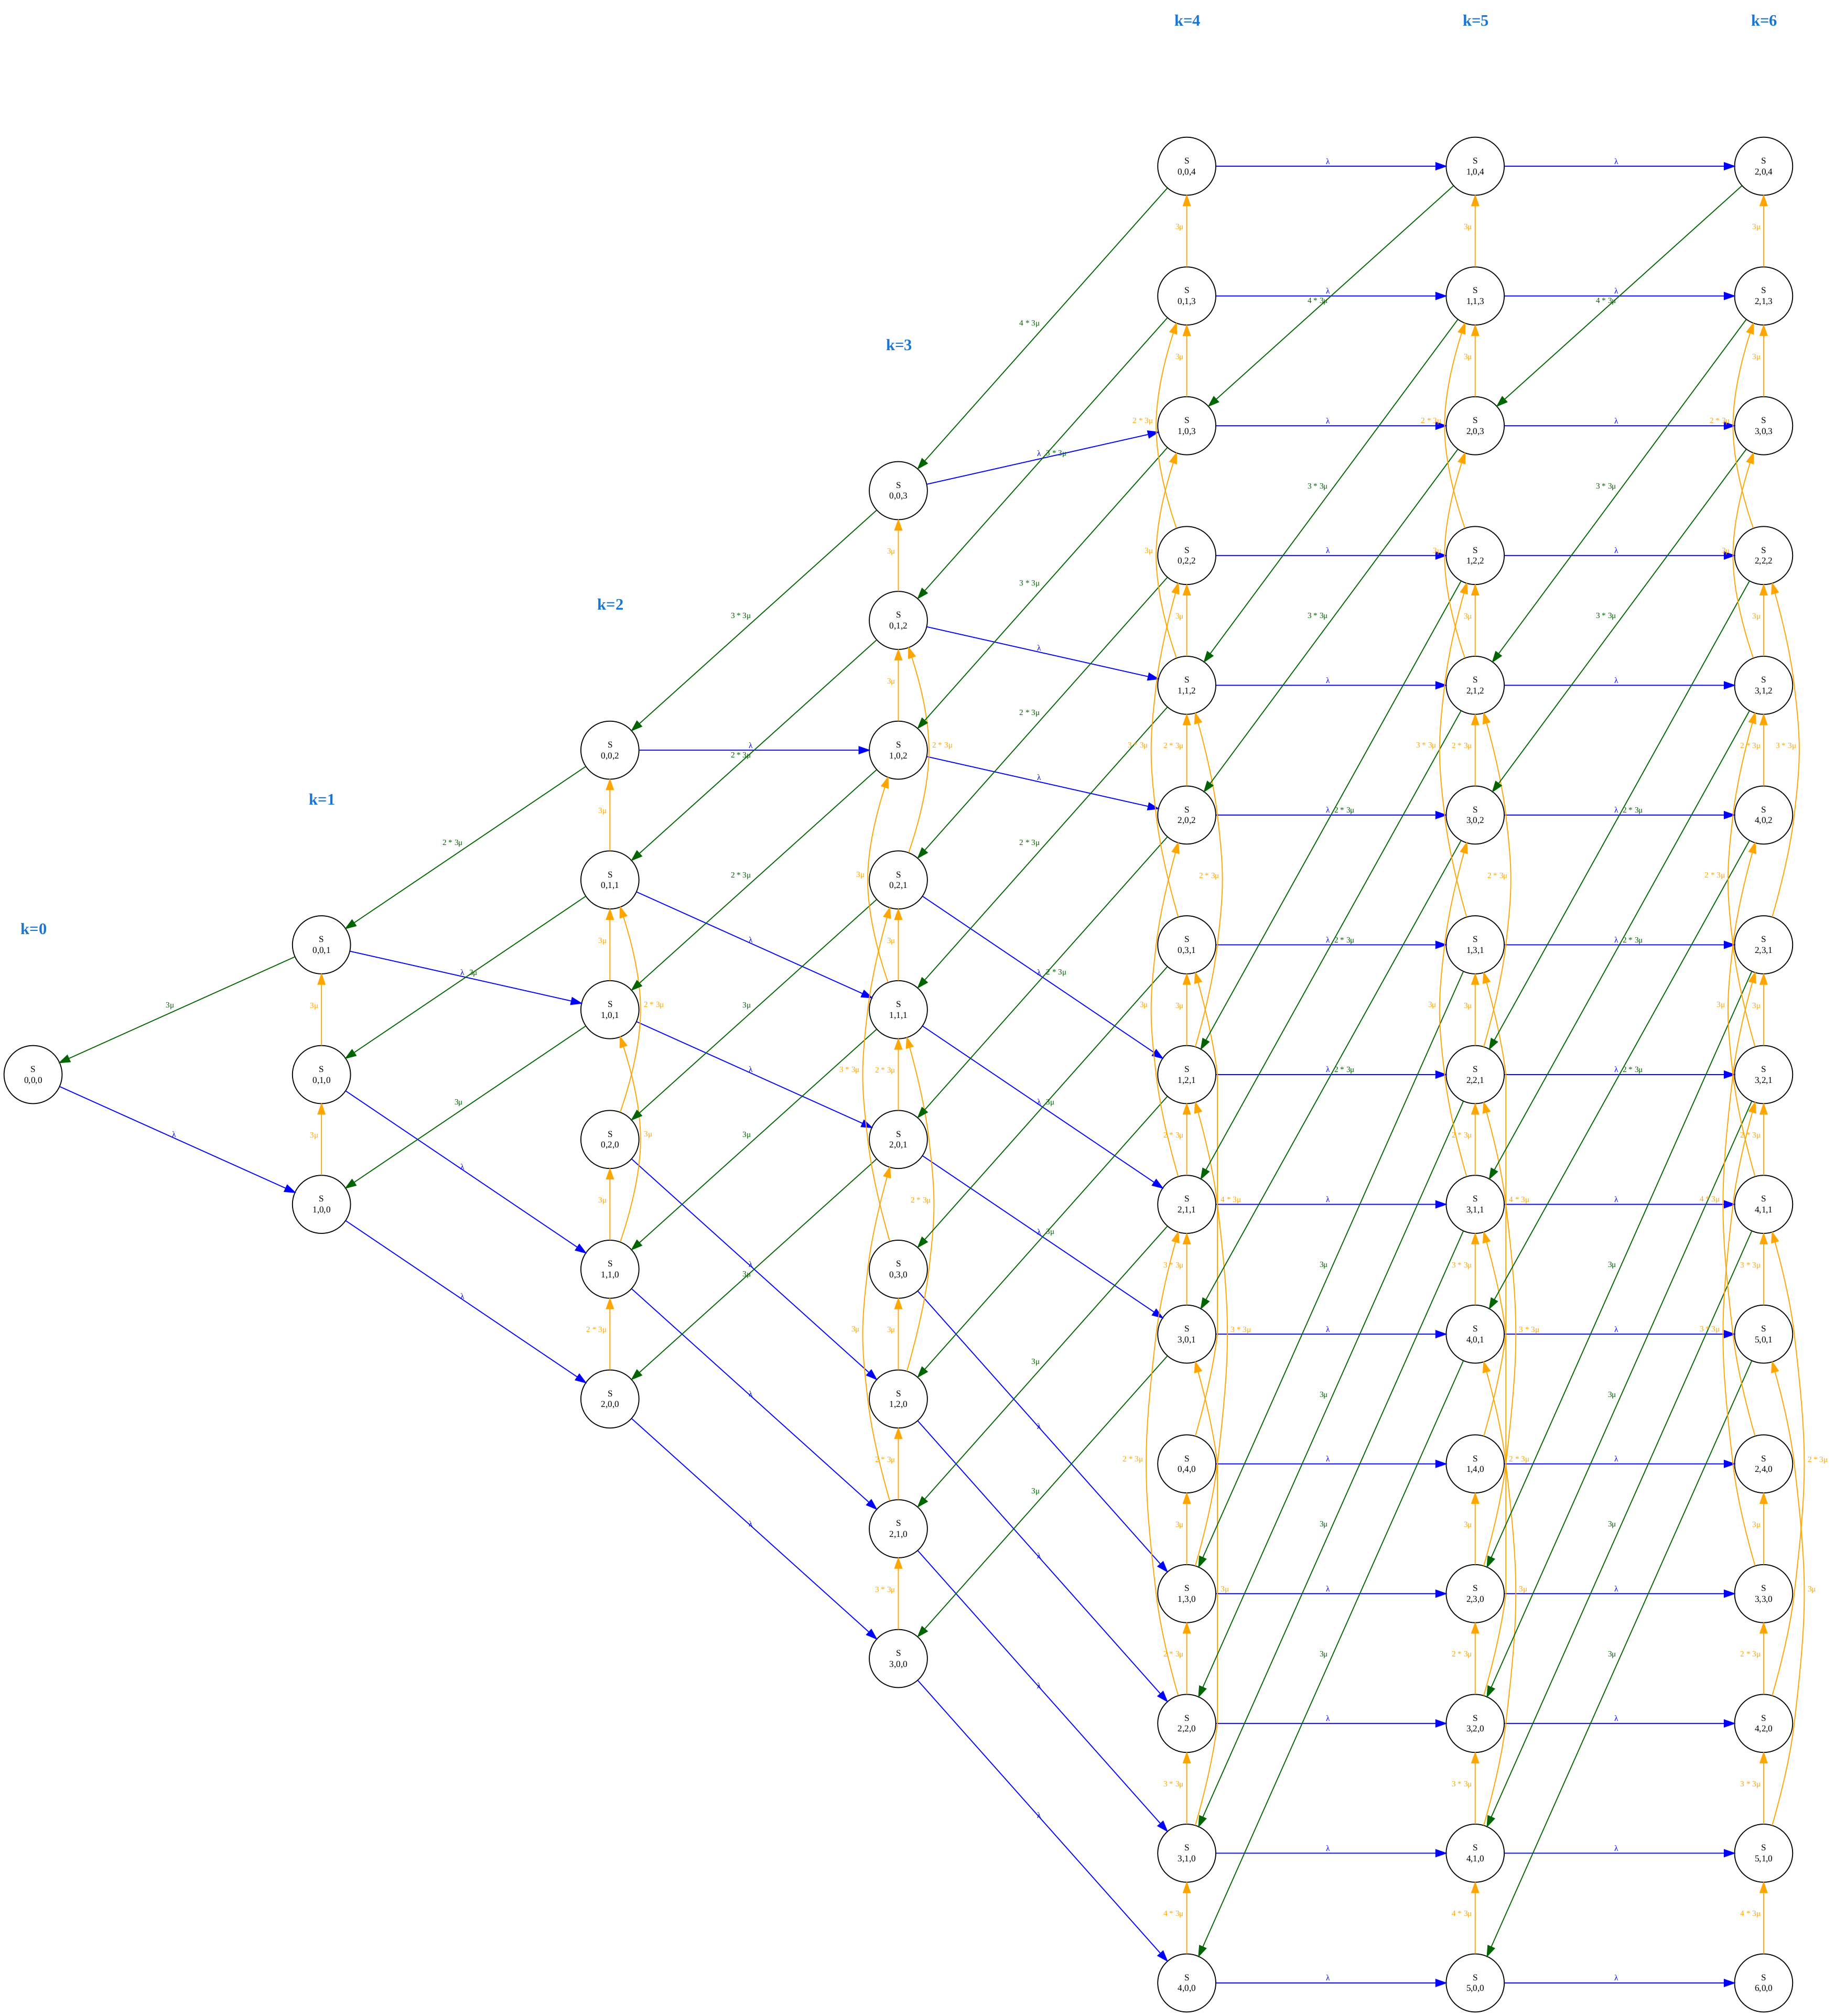

In [17]:
# --- ЗАДАНИЕ 2: МЕТОД ЭТАПОВ (ГРАФ И УРАВНЕНИЯ) ---

system("apt-get update -qq")
system("apt-get install -y librsvg2-dev libxml2-dev")

if (!require("DiagrammeR")) install.packages("DiagrammeR", repos = "http://cran.us.r-project.org")
if (!require("V8")) install.packages("V8", repos = "http://cran.us.r-project.org")
if (!require("rsvg")) install.packages("rsvg", repos = "http://cran.us.r-project.org", type = 'source')
if (!require("DiagrammeRsvg")) install.packages("DiagrammeRsvg", repos = "http://cran.us.r-project.org")

library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)
library(IRdisplay)

# Исходные данные
lambda <- 1.6003
mu_base <- 0.2475597
k_erlang <- 3
mu_stage <- k_erlang * mu_base

M_chan <- 4
N_q <- 2
K_max <- M_chan + N_q

states <- list()
edges_temp <- list() # Временный список для избежания ошибки Colab

# Функция добавления состояния S(i1, i2, i3)
add_s <- function(i1, i2, i3) {
  name <- paste0("S_", i1, "_", i2, "_", i3)
  if (!(name %in% names(states))) {
    states[[name]] <<- list(i1=i1, i2=i2, i3=i3, name=name)
    return(TRUE)
  }
  return(FALSE)
}

add_s(0, 0, 0)
queue <- list(c(0, 0, 0))
head <- 1

# Генерация всех возможных состояний
while(head <= length(queue)) {
  curr <- queue[[head]]; head <- head + 1
  i1 <- curr[1]; i2 <- curr[2]; i3 <- curr[3]
  k_total <- i1 + i2 + i3
  curr_name <- paste0("S_", i1, "_", i2, "_", i3)

  # 1. Поступление новой заявки (lambda)
  if (k_total < K_max) {
    if (add_s(i1 + 1, i2, i3)) queue <- append(queue, list(c(i1 + 1, i2, i3)))
    edges_temp[[length(edges_temp)+1]] <- c(curr_name, paste0("S_", i1+1, "_", i2, "_", i3), "λ", "blue")
  }

  # Распределение каналов обслуживания
  active_i3 <- min(i3, M_chan)
  active_i2 <- min(i2, M_chan - active_i3)
  active_i1 <- min(i1, M_chan - active_i3 - active_i2)

  # 2. Переход со стадии 1 на стадию 2
  if (active_i1 > 0) {
    if (add_s(i1 - 1, i2 + 1, i3)) queue <- append(queue, list(c(i1 - 1, i2 + 1, i3)))
    rate_str <- ifelse(active_i1 == 1, "3μ", paste0(active_i1, " * 3μ"))
    edges_temp[[length(edges_temp)+1]] <- c(curr_name, paste0("S_", i1-1, "_", i2+1, "_", i3), rate_str, "orange")
  }

  # 3. Переход со стадии 2 на стадию 3
  if (active_i2 > 0) {
    if (add_s(i1, i2 - 1, i3 + 1)) queue <- append(queue, list(c(i1, i2 - 1, i3 + 1)))
    rate_str <- ifelse(active_i2 == 1, "3μ", paste0(active_i2, " * 3μ"))
    edges_temp[[length(edges_temp)+1]] <- c(curr_name, paste0("S_", i1, "_", i2-1, "_", i3+1), rate_str, "orange")
  }

  # 4. Завершение обслуживания (уход из системы)
  if (active_i3 > 0) {
    if (add_s(i1, i2, i3 - 1)) queue <- append(queue, list(c(i1, i2, i3 - 1)))
    rate_str <- ifelse(active_i3 == 1, "3μ", paste0(active_i3, " * 3μ"))
    edges_temp[[length(edges_temp)+1]] <- c(curr_name, paste0("S_", i1, "_", i2, "_", i3-1), rate_str, "darkgreen")
  }
}

cat("Сгенерировано состояний:", length(states), "\n")

# --- ФОРМИРОВАНИЕ ИДЕАЛЬНОГО ГРАФА (Сетка neato) ---
graph_str <- "digraph G {\n  layout=neato;\n  splines=true;\n  overlap=false;\n  node [shape=circle, width=0.8, fixedsize=true, fontsize=9, style=filled, fillcolor=white];\n  edge [fontsize=8];\n"

# Присваиваем координаты каждому из 84 узлов
for (k in 0:K_max) {
  # Находим все состояния, где ровно k заявок
  nodes_k <- names(states)[sapply(names(states), function(n) (states[[n]]$i1 + states[[n]]$i2 + states[[n]]$i3) == k)]

  if (length(nodes_k) > 0) {
    # Сортируем узлы в колонке: сначала те, где больше i3, затем i2 (от самых готовых к самым начальным)
    nodes_k <- nodes_k[order(
      -sapply(nodes_k, function(n) states[[n]]$i3),
      -sapply(nodes_k, function(n) states[[n]]$i2)
    )]

    n_nodes <- length(nodes_k)
    for (idx in 1:n_nodes) {
      name <- nodes_k[idx]

      # Координата X зависит только от k (колонки)
      x_pos <- k * 4.0
      # Координата Y выстраивает узлы вертикально и центрирует колонку
      y_pos <- (n_nodes - 1) * 0.9 - (idx - 1) * 1.8

      label <- paste0("S\\n", states[[name]]$i1, ",", states[[name]]$i2, ",", states[[name]]$i3)
      graph_str <- paste0(graph_str, sprintf('  "%s" [label="%s", pos="%f,%f!"];\n', name, label, x_pos, y_pos))

      # Сохраняем координаты в объект (на всякий случай)
      states[[name]]$x <- x_pos; states[[name]]$y <- y_pos
    }

    # Добавляем красивую подпись над каждой колонкой (k=0, k=1...)
    graph_str <- paste0(graph_str, sprintf('  "K_label_%d" [shape=none, label=<<font color="#1976D2" point-size="16"><b>k=%d</b></font>>, pos="%f,%f!"];\n', k, k, k*4.0, (n_nodes - 1) * 0.9 + 2.0))
  }
}

# Добавляем все раскрашенные связи
for (e in edges_temp) {
  graph_str <- paste0(graph_str, sprintf('  "%s" -> "%s" [label="%s", color="%s", fontcolor="%s"];\n', e[1], e[2], e[3], e[4], e[4]))
}
graph_str <- paste0(graph_str, "}")

g <- grViz(graph_str)
rsvg_png(charToRaw(export_svg(g)), file="erlang_grid.png", width=3500)
display_png(file="erlang_grid.png")

### Уравнения Колмогорова и решение системы

Из-за огромной размерности пространства состояний (84 узла), полная запись системы дифференциальных уравнений Колмогорова займет несколько страниц. Запишем общий вид уравнений для первых нескольких базовых состояний графа:

1. Для полностью пустой системы $S_{0,0,0}$:
$$ \frac{dP_{0,0,0}(t)}{dt} = - \lambda P_{0,0,0}(t) + 3\mu P_{0,0,1}(t) $$

2. Для состояния с одной заявкой на первой стадии $S_{1,0,0}$:
$$ \frac{dP_{1,0,0}(t)}{dt} = \lambda P_{0,0,0}(t) - (\lambda + 3\mu) P_{1,0,0}(t) + 3\mu P_{1,0,1}(t) $$

3. Для состояния с одной заявкой на второй стадии $S_{0,1,0}$:
$$ \frac{dP_{0,1,0}(t)}{dt} = 3\mu P_{1,0,0}(t) - (\lambda + 3\mu) P_{0,1,0}(t) + 3\mu P_{0,1,1}(t) $$

В стационарном режиме (при $t \to \infty$) производные равны нулю. Для нахождения финальных вероятностей сформируем инфинитезимальную матрицу интенсивностей $Q$ размерностью $84 \times 84$ программным методом и решим СЛАУ $P \cdot Q = 0$ с учетом нормировочного условия $\sum_{i=1}^{84} P_i = 1$.

### Описание структуры графа состояний (M/E3/4/2)

В связи с использованием аппроксимации Эрланга 3-го порядка ($E_3$), процесс обслуживания каждой заявки искусственно разбивается на 3 последовательные экспоненциальные фазы с интенсивностью $\mu_{stage} = 3\mu$.

Состояние системы описывается вектором $S(i_1, i_2, i_3)$, где:
* $i_1$ — количество заявок на первой фазе обслуживания (или ожидающих в очереди);
* $i_2$ — количество заявок на второй фазе обслуживания;
* $i_3$ — количество заявок на третьей (финальной) фазе обслуживания.

Общее количество заявок в системе равно $k = i_1 + i_2 + i_3$. Так как система имеет 4 канала и очередь на 2 места, максимальное значение $k_{max} = 6$. Следовательно, граф состоит из 84 возможных состояний.

Для наглядности граф сгенерирован в виде **сеточной структуры**, сгруппированной по столбцам:

**1. Столбцы (ось X):**
Каждый столбец соответствует общему числу заявок в системе (от $k=0$ до $k=6$).
**Синие стрелки** направлены строго вправо — они отображают поступление новой заявки от программиста с интенсивностью $\lambda$. При поступлении новой заявки она всегда попадает на первую стадию, поэтому индекс $i_1$ увеличивается на 1, а общее число заявок $k$ также увеличивается.

**2. Продвижение по фазам внутри столбца (ось Y):**
Внутри каждого столбца состояния отсортированы по "степени готовности" заявок.
**Оранжевые стрелки** направлены преимущественно вверх. Они отображают процесс обработки заявки сервером: переход со стадии 1 на стадию 2, либо со стадии 2 на стадию 3. При этом общее число заявок $k$ не меняется (мы остаемся в том же столбце).
Интенсивность перехода зависит от того, сколько заявок на данной стадии РЕАЛЬНО обрабатываются серверами (с учетом ограничения $M_{chan} = 4$). Серверы в первую очередь берут заявки, находящиеся на финальных стадиях ($i_3$, затем $i_2$, затем $i_1$).

**3. Выход из системы:**
**Зеленые стрелки** направлены строго влево — они отображают успешное завершение обслуживания заявки (выход с 3-й стадии). Индекс $i_3$ уменьшается на 1, общее количество заявок $k$ уменьшается на 1, и система переходит в предыдущий левый столбец. Интенсивность выхода равна числу заявок на 3-й стадии, умноженному на $3\mu$.

In [16]:
# --- РЕШЕНИЕ СИСТЕМЫ И РАСЧЕТ ХАРАКТЕРИСТИК ---

num_states <- length(states)
state_names <- names(states)

# 1. Создаем пустую матрицу 84x84
Q <- matrix(0, nrow = num_states, ncol = num_states)
rownames(Q) <- state_names
colnames(Q) <- state_names

# 2. Заполняем матрицу Q интенсивностями переходов
for (name in state_names) {
  s <- states[[name]]
  i1 <- s$i1; i2 <- s$i2; i3 <- s$i3
  k <- i1 + i2 + i3
  idx <- which(state_names == name)

  # Поступление заявок
  if (k < K_max) {
    next_name <- paste0("S_", i1+1, "_", i2, "_", i3)
    Q[idx, which(state_names == next_name)] <- lambda
  }

  active_i3 <- min(i3, M_chan)
  active_i2 <- min(i2, M_chan - active_i3)
  active_i1 <- min(i1, M_chan - active_i3 - active_i2)

  # Продвижение по фазам Эрланга
  if (active_i1 > 0) {
    next_name <- paste0("S_", i1-1, "_", i2+1, "_", i3)
    Q[idx, which(state_names == next_name)] <- active_i1 * mu_stage
  }
  if (active_i2 > 0) {
    next_name <- paste0("S_", i1, "_", i2-1, "_", i3+1)
    Q[idx, which(state_names == next_name)] <- active_i2 * mu_stage
  }
  if (active_i3 > 0) {
    next_name <- paste0("S_", i1, "_", i2, "_", i3-1)
    Q[idx, which(state_names == next_name)] <- active_i3 * mu_stage
  }
}

# Заполняем диагональ
for (i in 1:num_states) Q[i,i] <- -sum(Q[i, -i])

# 3. Решаем СЛАУ
A_mat <- t(Q)
b_vec <- rep(0, num_states)
# Нормировочное уравнение
A_mat[num_states, ] <- 1
b_vec[num_states] <- 1

P_final <- solve(A_mat, b_vec)

# 4. Расчет характеристик эффективности СМО
# L - среднее число заявок в системе
L_sys <- 0
# P_rej - вероятность отказа (когда в системе ровно K_max заявок)
P_rej <- 0

for (i in 1:num_states) {
  s <- states[[state_names[i]]]
  k <- s$i1 + s$i2 + s$i3
  L_sys <- L_sys + k * P_final[i]

  if (k == K_max) {
    P_rej <- P_rej + P_final[i]
  }
}

# Абсолютная пропускная способность (успешно вошедшие заявки)
A_throughput <- lambda * (1 - P_rej)

# Среднее время в системе (по формуле Литтла: L = A * W => W = L / A)
W_sys <- L_sys / A_throughput


cat("=== ФИНАЛЬНЫЕ ХАРАКТЕРИСТИКИ СИСТЕМЫ (МЕТОД ЭТАПОВ E3) ===\n")
cat("Всего проанализировано состояний:", num_states, "\n")
cat("Вероятность того, что система пуста P(0,0,0) =", round(P_final[1], 5), "\n")
cat("Вероятность отказа (очередь переполнена) P_отк =", round(P_rej, 5), "\n\n")
cat("Абсолютная пропускная способность A =", round(A_throughput, 4), "заявок/ед.вр.\n")
cat("Среднее число заявок в системе L =", round(L_sys, 4), "\n")
cat("Среднее время пребывания заявки в системе W =", round(W_sys, 4), "\n")

=== ФИНАЛЬНЫЕ ХАРАКТЕРИСТИКИ СИСТЕМЫ (МЕТОД ЭТАПОВ E3) ===
Всего проанализировано состояний: 65 
Вероятность того, что система пуста P(0,0,0) = 0.00115 
Вероятность отказа (очередь переполнена) P_отк = 0.40822 

Абсолютная пропускная способность A = 0.947 заявок/ед.вр.
Среднее число заявок в системе L = 4.9372 
Среднее время пребывания заявки в системе W = 5.2134 
